# Ablation Analysis — Student v2 + Hard Prediction Metric

**Data:** Flan-T5-Large base, student v1, student v2 — all on Self-Instruct  
**Metrics:** Similarity, Similarity Hard Prediction, ROUGE-L, METEOR  
**Sections:**
1. Base vs v1 (with `similarity_hard_prediction_mean`)
2. Base vs v2
3. v1 vs v2

In [1]:
import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 120, 'savefig.dpi': 150,
    'axes.grid': True, 'grid.alpha': 0.3,
})

In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

flan_base = load_json('ablation_base_flan_t5_large_config.json')['results']
flan_v1 = load_json('ablation_flan_t5_large_student_v1_self_instruct_config.json')['results']
flan_v2 = load_json('ablation_flan_t5_large_student_v2_self_instruct_config.json')['results']

bl_base = flan_base['baseline_no_drop']
bl_v1 = flan_v1['baseline_no_drop']
bl_v2 = flan_v2['baseline_no_drop']

print('Baselines:')
for name, bl in [('Base', bl_base), ('V1', bl_v1), ('V2', bl_v2)]:
    print(f'  {name}: sim={bl["similarity_mean"]:.4f}, sim_hard={bl["similarity_hard_prediction_mean"]:.4f}, '
          f'rougeL={bl["rouge"]["rougeL"]:.4f}, meteor={bl["meteor_mean"]:.4f}')

Baselines:
  Base: sim=0.6549, sim_hard=0.7734, rougeL=0.2826, meteor=0.1749
  V1: sim=0.5896, sim_hard=0.5859, rougeL=0.2465, meteor=0.2006
  V2: sim=0.6572, sim_hard=0.7812, rougeL=0.3007, meteor=0.1924


In [3]:
# === Shared helpers ===

def get_layer_deltas(results, bl, component, n=24):
    rows = []
    for i in range(n):
        k = f'drop_{component}_block_{i}'
        if k in results:
            v = results[k]
            rows.append({
                'layer': i,
                'delta_sim': v['similarity_mean'] - bl['similarity_mean'],
                'delta_hard': v['similarity_hard_prediction_mean'] - bl['similarity_hard_prediction_mean'],
                'delta_rougeL': v['rouge']['rougeL'] - bl['rouge']['rougeL'],
                'delta_meteor': v['meteor_mean'] - bl['meteor_mean'],
            })
    return pd.DataFrame(rows)

def parse_attention_masking(results, bl):
    rows = []
    for k, v in results.items():
        if not k.startswith('mask_') or 'attention' not in k:
            continue
        ratio = float(k.split('_')[-1])
        attn_type = 'self+cross' if 'self_cross_attention' in k else ('cross' if 'cross_attention' in k else 'self')
        scope = 'both' if 'encoder_decoder' in k else ('encoder' if 'encoder' in k else 'decoder')
        rows.append({'scope': scope, 'attn_type': attn_type, 'ratio': ratio,
                     'Similarity': v['similarity_mean'], 'Hard Pred': v['similarity_hard_prediction_mean'],
                     'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

def parse_gaussian(results, bl):
    rows = []
    for k, v in results.items():
        if not k.startswith('add_gaussian_noise'):
            continue
        parts = k.replace('add_gaussian_noise_', '').rsplit('_', 1)
        sigma = float(parts[-1])
        target = parts[0]
        if 'feed_forward' in target:
            scope = 'encoder FF' if 'encoder' in target else ('decoder FF' if 'decoder' in target else 'all FF')
        else:
            scope = 'encoder full' if 'encoder' in target else ('decoder full' if 'decoder' in target else 'all full')
        rows.append({'scope': scope, 'sigma': sigma,
                     'Similarity': v['similarity_mean'], 'Hard Pred': v['similarity_hard_prediction_mean'],
                     'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

def plot_attn_masking(df, title, ax):
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['Similarity'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('Similarity')
    ax.set_title(title); ax.legend(fontsize=7, loc='lower left')

---
## 1. Flan-T5 Base vs Student v1 (+ Hard Prediction)

### 1.1 Single Encoder Layer Dropping

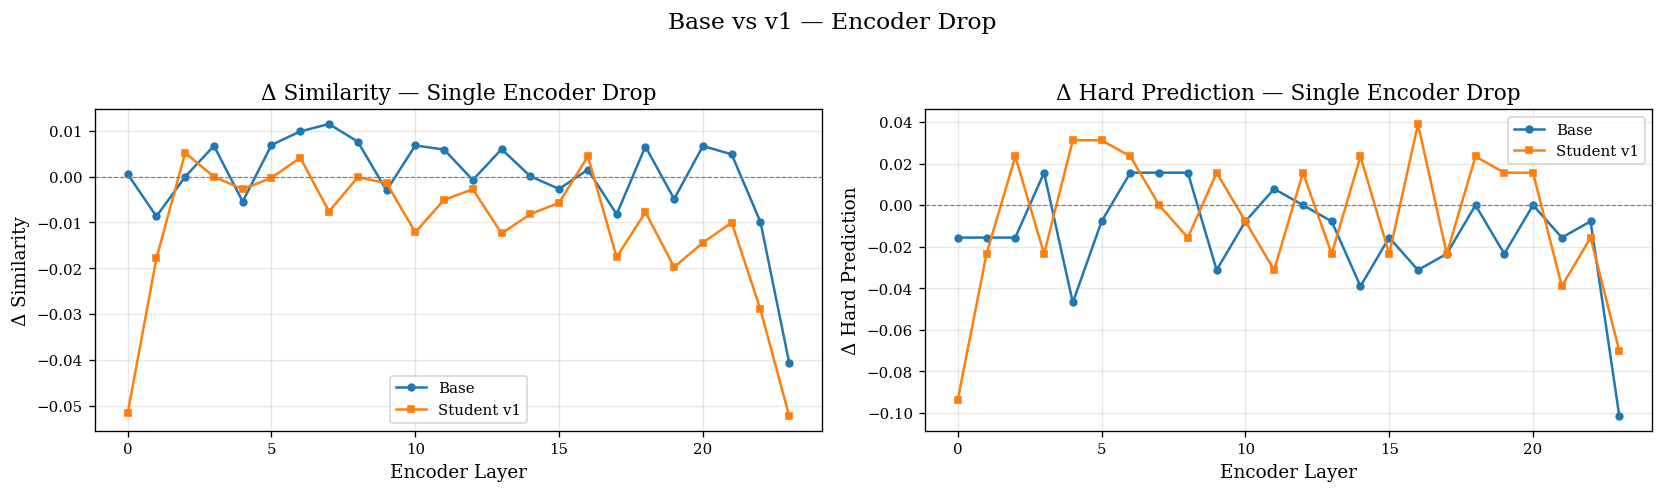

In [4]:
df_enc_base = get_layer_deltas(flan_base, bl_base, 'encoder')
df_enc_v1 = get_layer_deltas(flan_v1, bl_v1, 'encoder')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, label in [(axes[0], 'delta_sim', 'Δ Similarity'), (axes[1], 'delta_hard', 'Δ Hard Prediction')]:
    ax.plot(df_enc_base['layer'], df_enc_base[metric], 'o-', label='Base', markersize=4)
    ax.plot(df_enc_v1['layer'], df_enc_v1[metric], 's-', label='Student v1', markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_xlabel('Encoder Layer'); ax.set_ylabel(label)
    ax.set_title(f'{label} — Single Encoder Drop'); ax.legend()
fig.suptitle('Base vs v1 — Encoder Drop', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.2 Single Decoder Layer Dropping

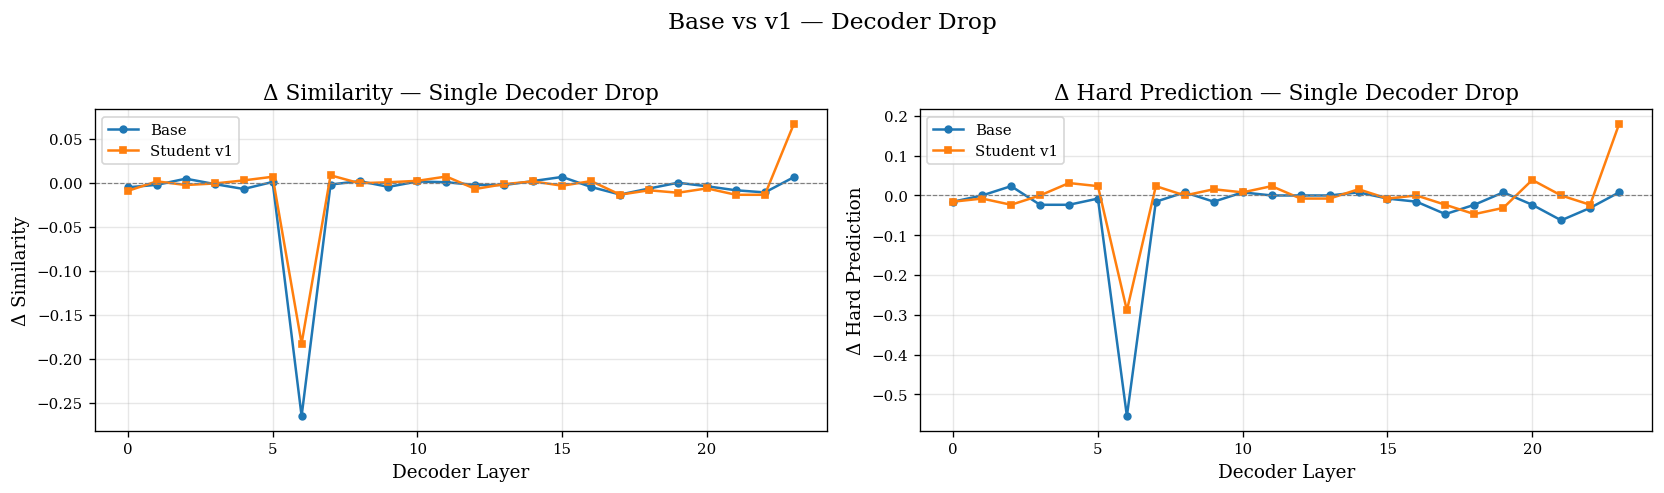

In [5]:
df_dec_base = get_layer_deltas(flan_base, bl_base, 'decoder')
df_dec_v1 = get_layer_deltas(flan_v1, bl_v1, 'decoder')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, label in [(axes[0], 'delta_sim', 'Δ Similarity'), (axes[1], 'delta_hard', 'Δ Hard Prediction')]:
    ax.plot(df_dec_base['layer'], df_dec_base[metric], 'o-', label='Base', markersize=4)
    ax.plot(df_dec_v1['layer'], df_dec_v1[metric], 's-', label='Student v1', markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_xlabel('Decoder Layer'); ax.set_ylabel(label)
    ax.set_title(f'{label} — Single Decoder Drop'); ax.legend()
fig.suptitle('Base vs v1 — Decoder Drop', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.3 Attention Masking

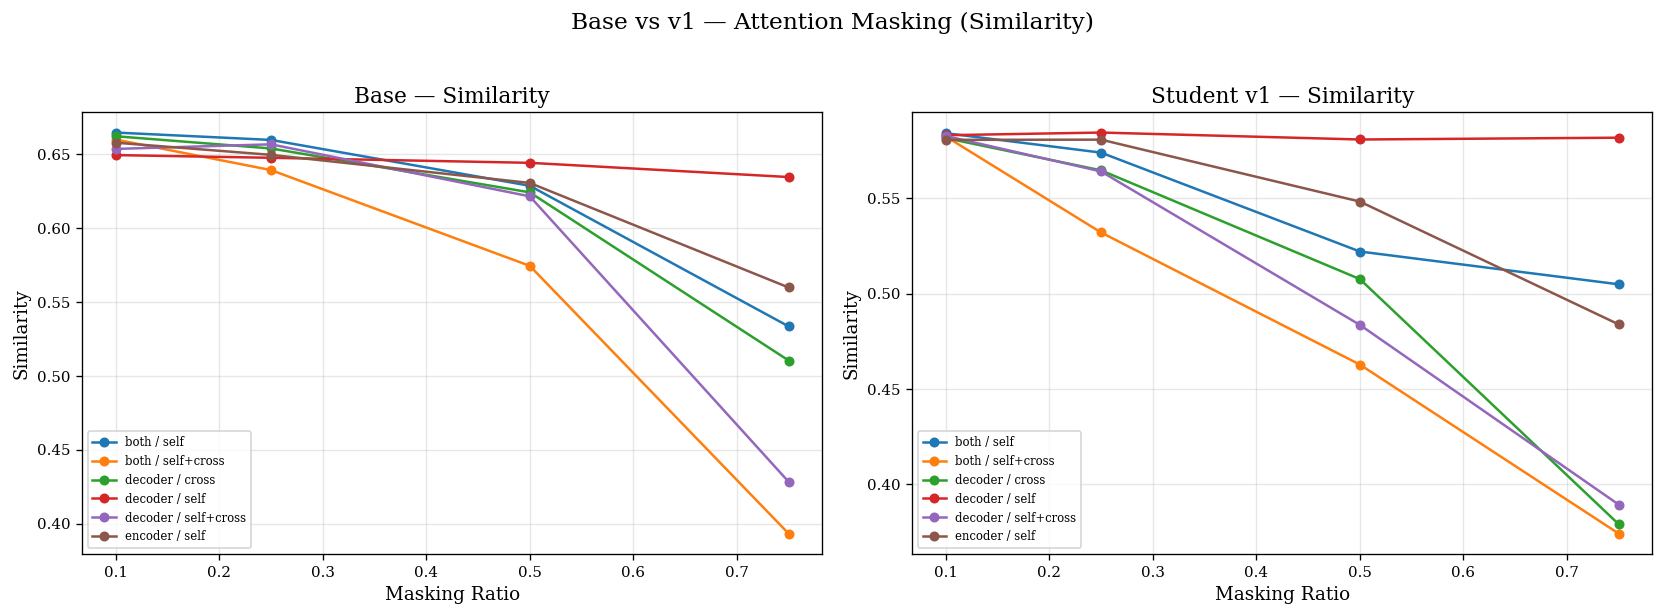

In [6]:
df_attn_base = parse_attention_masking(flan_base, bl_base)
df_attn_v1 = parse_attention_masking(flan_v1, bl_v1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_attn_masking(df_attn_base, 'Base — Similarity', axes[0])
plot_attn_masking(df_attn_v1, 'Student v1 — Similarity', axes[1])
fig.suptitle('Base vs v1 — Attention Masking (Similarity)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

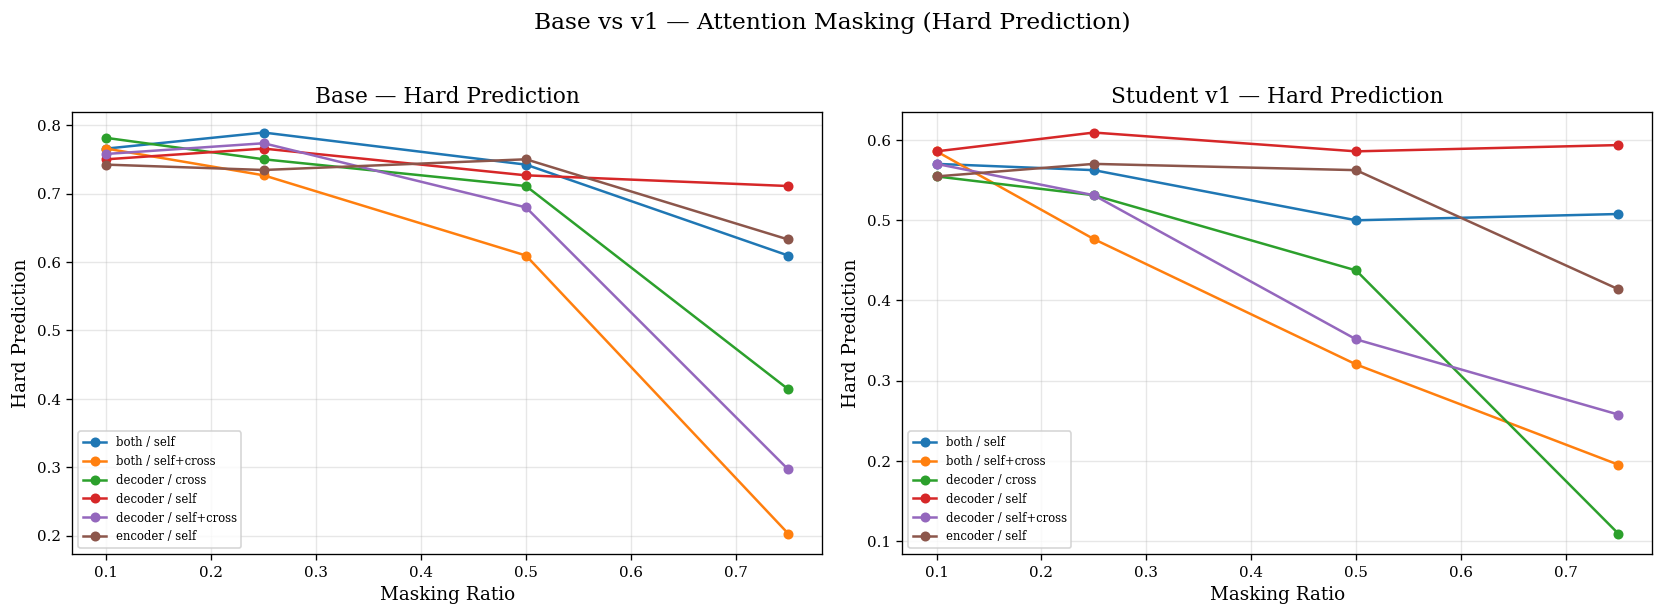

In [7]:
# Hard prediction version
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], df_attn_base, 'Base'), (axes[1], df_attn_v1, 'Student v1')]:
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['Hard Pred'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('Hard Prediction')
    ax.set_title(f'{title} — Hard Prediction'); ax.legend(fontsize=7, loc='lower left')
fig.suptitle('Base vs v1 — Attention Masking (Hard Prediction)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 1.4 Gaussian Noise

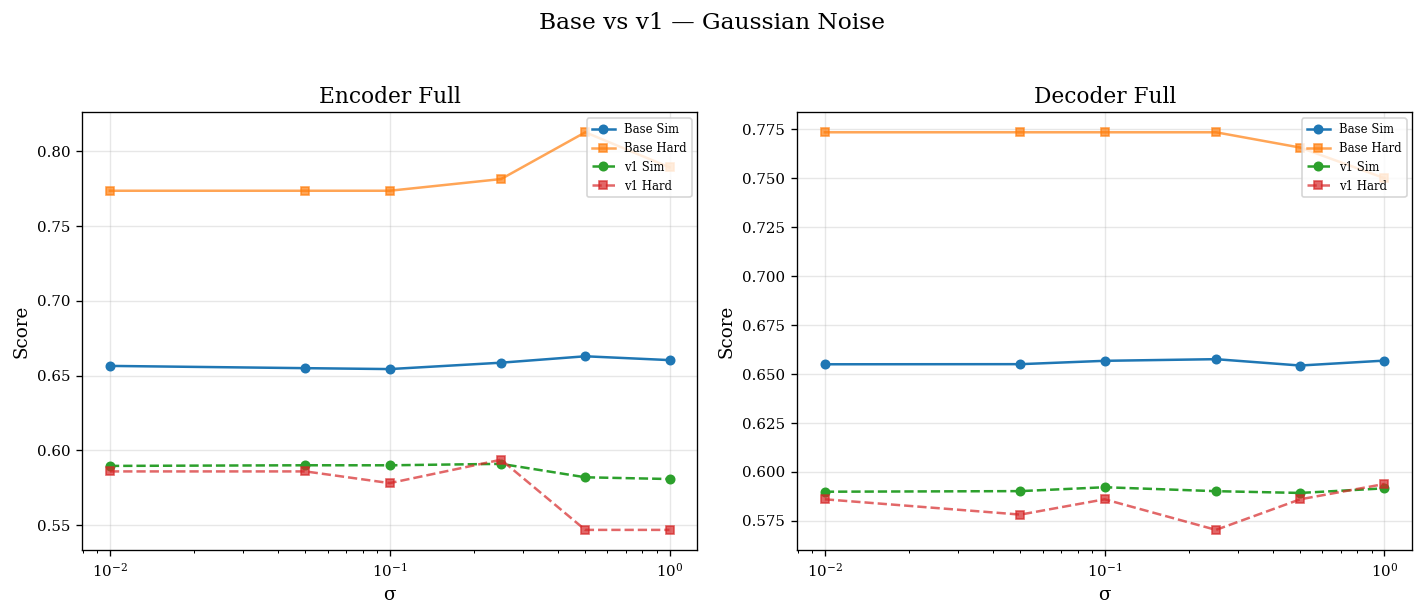

In [8]:
df_g_base = parse_gaussian(flan_base, bl_base)
df_g_v1 = parse_gaussian(flan_v1, bl_v1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scope_key, title in [(axes[0], 'encoder full', 'Encoder Full'), (axes[1], 'decoder full', 'Decoder Full')]:
    for df, lbl, ls in [(df_g_base, 'Base', '-'), (df_g_v1, 'v1', '--')]:
        sub = df[df['scope'] == scope_key].sort_values('sigma')
        ax.plot(sub['sigma'], sub['Similarity'], f'o{ls}', label=f'{lbl} Sim', markersize=5)
        ax.plot(sub['sigma'], sub['Hard Pred'], f's{ls}', label=f'{lbl} Hard', markersize=5, alpha=0.7)
    ax.set_xlabel('σ'); ax.set_ylabel('Score'); ax.set_title(title)
    ax.legend(fontsize=7); ax.set_xscale('log')
fig.suptitle('Base vs v1 — Gaussian Noise', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 2. Flan-T5 Base vs Student v2

### 2.1 Single Encoder Layer Dropping

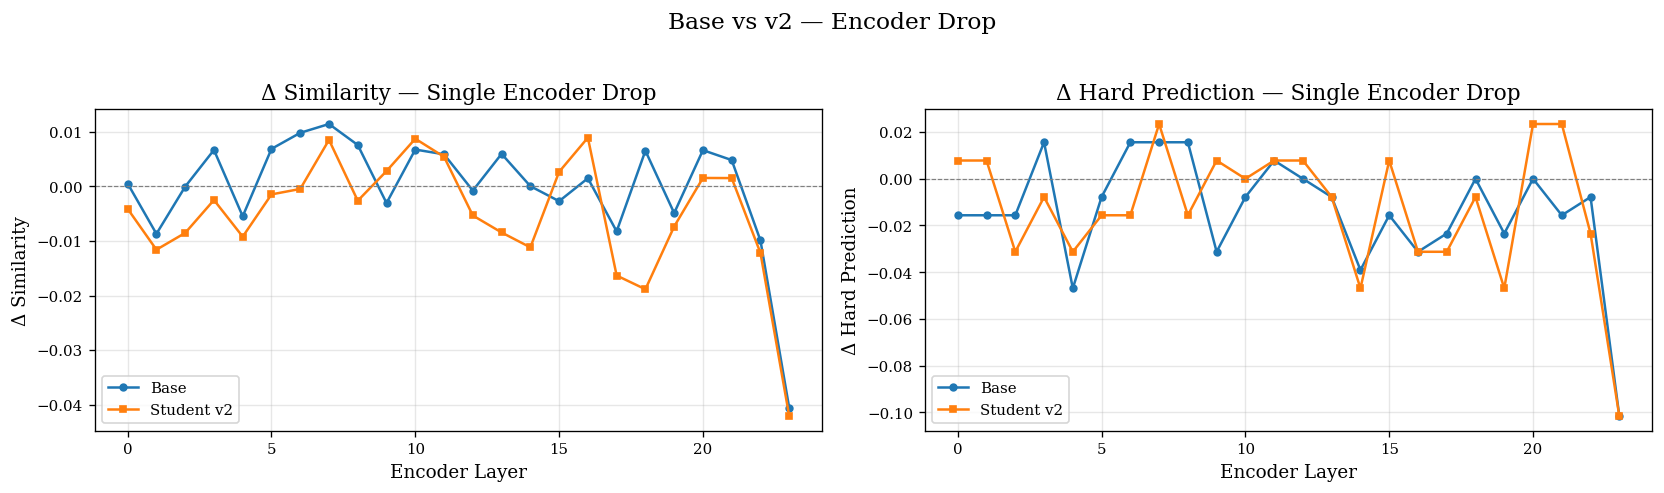

In [9]:
df_enc_v2 = get_layer_deltas(flan_v2, bl_v2, 'encoder')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, label in [(axes[0], 'delta_sim', 'Δ Similarity'), (axes[1], 'delta_hard', 'Δ Hard Prediction')]:
    ax.plot(df_enc_base['layer'], df_enc_base[metric], 'o-', label='Base', markersize=4)
    ax.plot(df_enc_v2['layer'], df_enc_v2[metric], 's-', label='Student v2', markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_xlabel('Encoder Layer'); ax.set_ylabel(label)
    ax.set_title(f'{label} — Single Encoder Drop'); ax.legend()
fig.suptitle('Base vs v2 — Encoder Drop', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.2 Single Decoder Layer Dropping

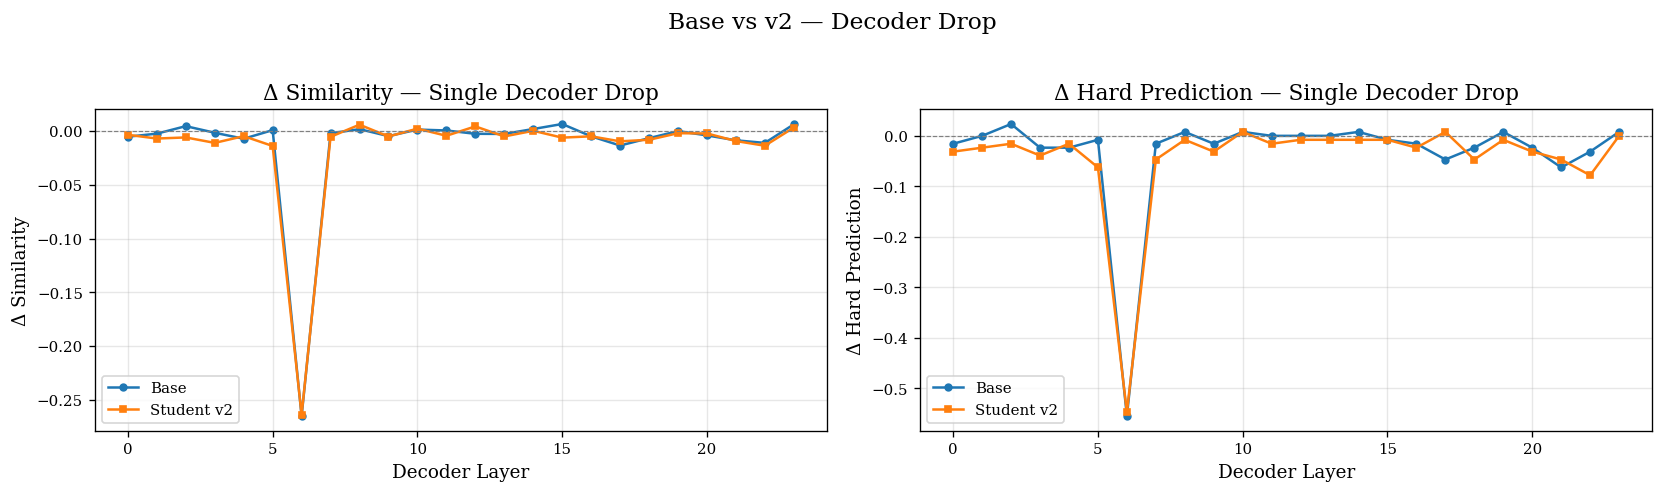

In [10]:
df_dec_v2 = get_layer_deltas(flan_v2, bl_v2, 'decoder')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, label in [(axes[0], 'delta_sim', 'Δ Similarity'), (axes[1], 'delta_hard', 'Δ Hard Prediction')]:
    ax.plot(df_dec_base['layer'], df_dec_base[metric], 'o-', label='Base', markersize=4)
    ax.plot(df_dec_v2['layer'], df_dec_v2[metric], 's-', label='Student v2', markersize=4)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_xlabel('Decoder Layer'); ax.set_ylabel(label)
    ax.set_title(f'{label} — Single Decoder Drop'); ax.legend()
fig.suptitle('Base vs v2 — Decoder Drop', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.3 Cumulative Layer Dropping

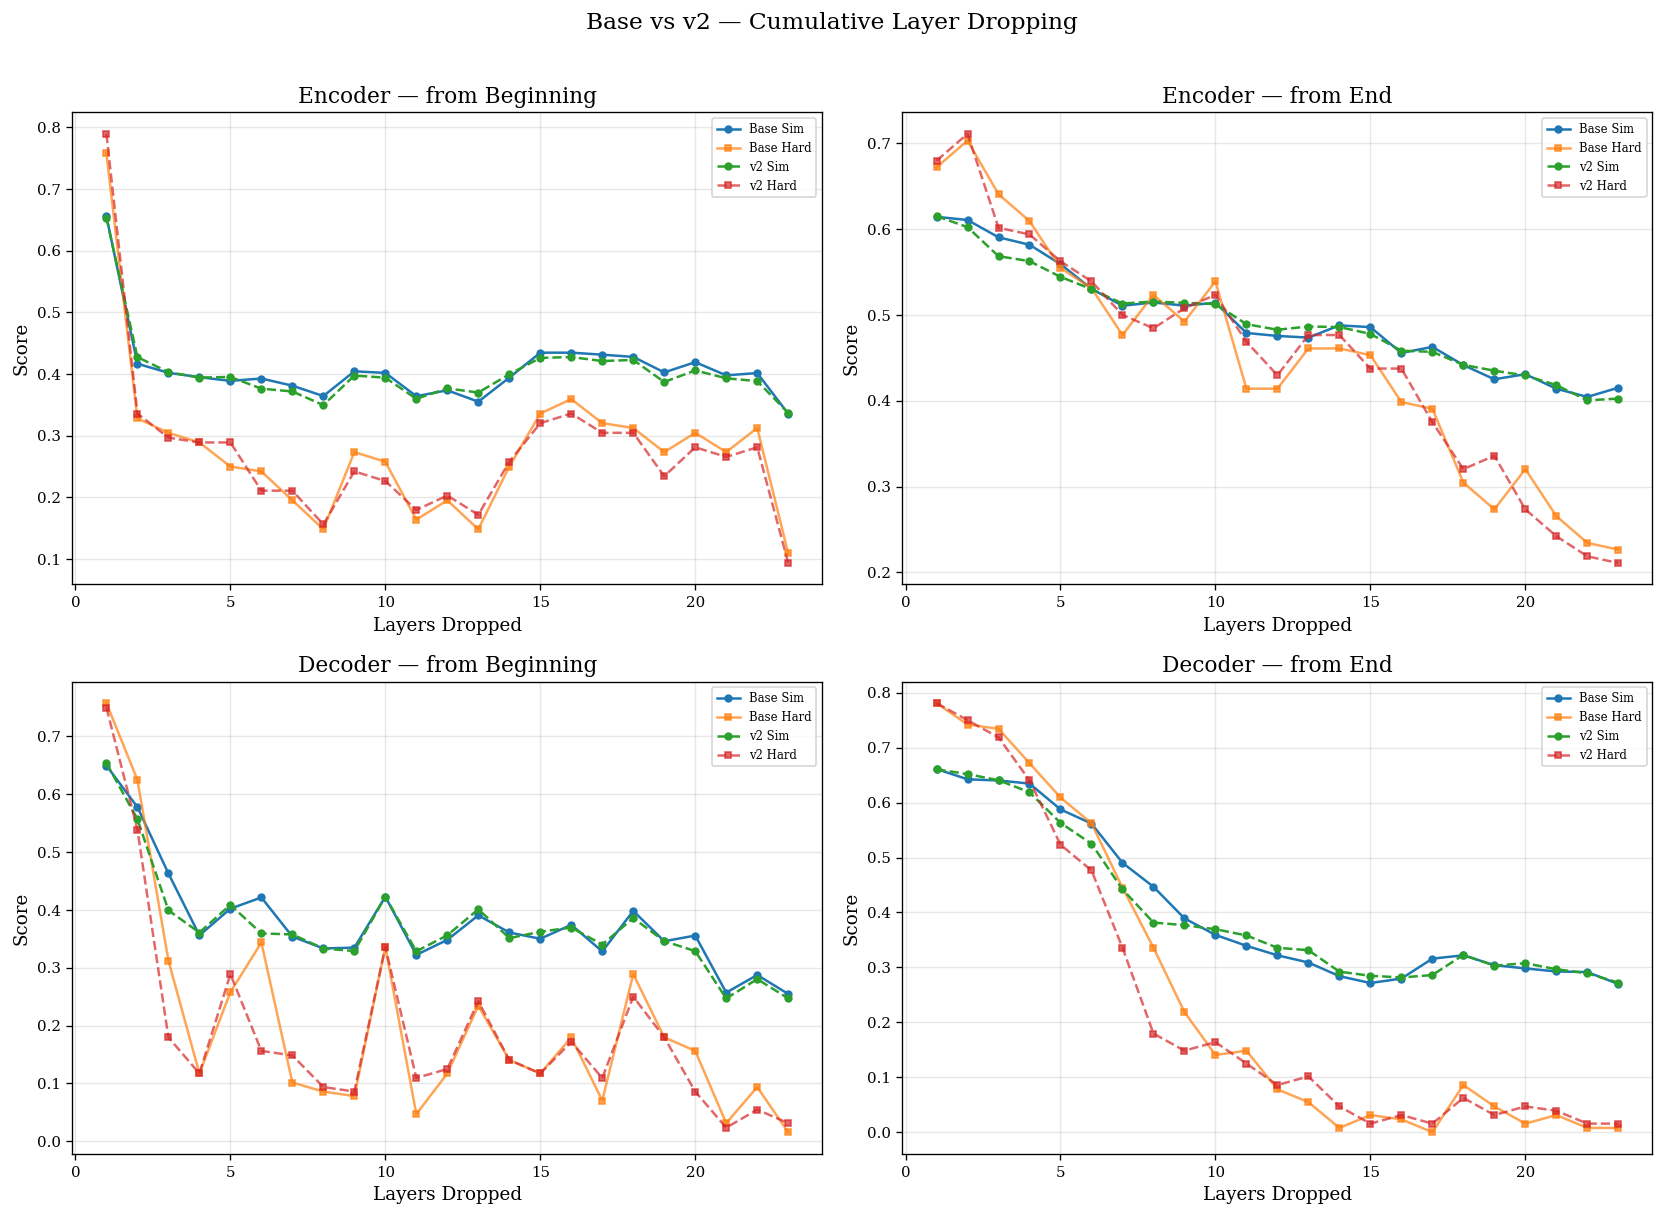

In [11]:
def get_cumulative(results, component, direction, n=23):
    rows = []
    if direction == 'beginning':
        for i in range(n):
            k = f'drop_{component}_block_from_beginning_{i}'
            if k in results:
                v = results[k]
                rows.append({'dropped': i+1, 'sim': v['similarity_mean'], 'hard': v['similarity_hard_prediction_mean'],
                             'rougeL': v['rouge']['rougeL'], 'meteor': v['meteor_mean']})
    else:
        for i in range(23, 0, -1):
            k = f'drop_{component}_block_from_end_{i}'
            if k in results:
                v = results[k]
                rows.append({'dropped': 24-i, 'sim': v['similarity_mean'], 'hard': v['similarity_hard_prediction_mean'],
                             'rougeL': v['rouge']['rougeL'], 'meteor': v['meteor_mean']})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, comp, direction, title in [
    (axes[0,0], 'encoder', 'beginning', 'Encoder — from Beginning'),
    (axes[0,1], 'encoder', 'end', 'Encoder — from End'),
    (axes[1,0], 'decoder', 'beginning', 'Decoder — from Beginning'),
    (axes[1,1], 'decoder', 'end', 'Decoder — from End'),
]:
    for results, lbl, ls in [(flan_base, 'Base', '-'), (flan_v2, 'v2', '--')]:
        df = get_cumulative(results, comp, direction)
        if len(df) > 0:
            ax.plot(df['dropped'], df['sim'], f'o{ls}', label=f'{lbl} Sim', markersize=4)
            ax.plot(df['dropped'], df['hard'], f's{ls}', label=f'{lbl} Hard', markersize=4, alpha=0.7)
    ax.set_xlabel('Layers Dropped'); ax.set_ylabel('Score')
    ax.set_title(title); ax.legend(fontsize=7)
fig.suptitle('Base vs v2 — Cumulative Layer Dropping', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### 2.4 Odd/Even Layer Dropping

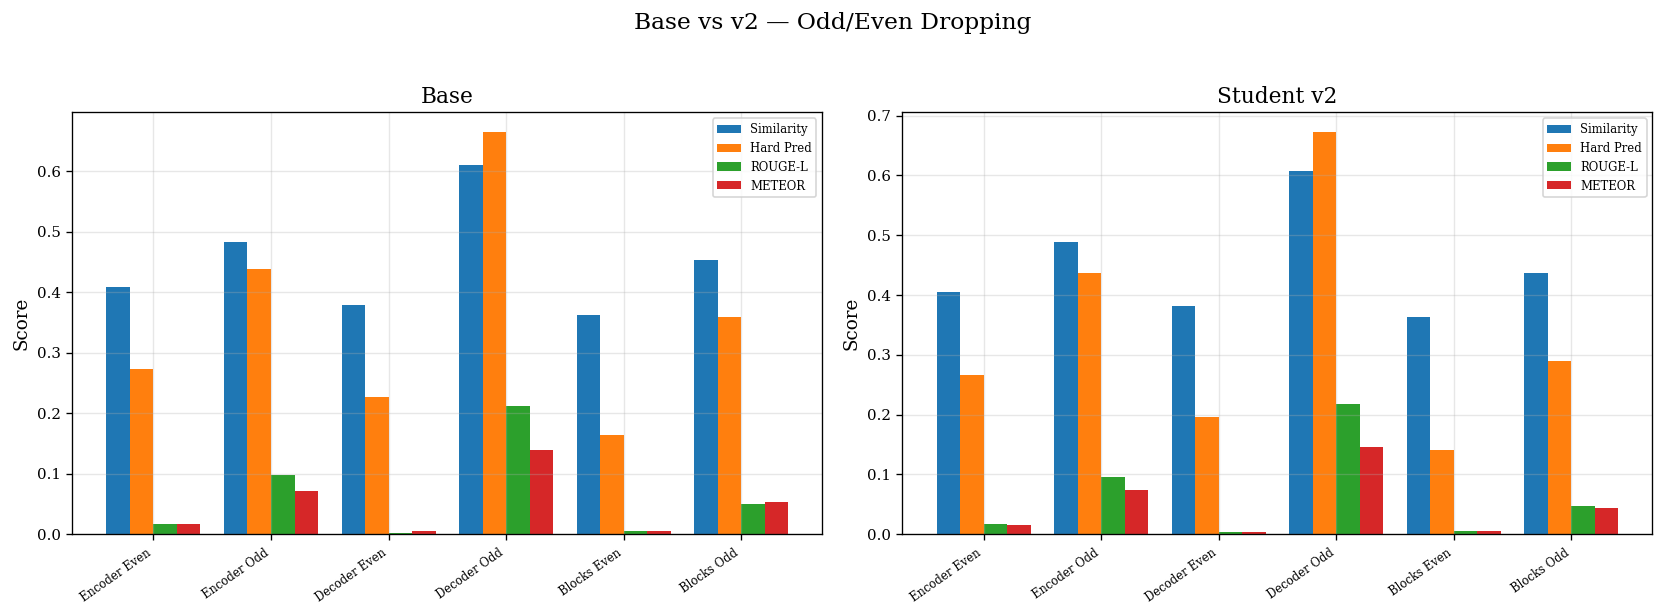

In [12]:
odd_even_keys = [
    'drop_encoder_block_all_even', 'drop_encoder_block_all_odd',
    'drop_decoder_block_all_even', 'drop_decoder_block_all_odd',
    'drop_blocks_all_even', 'drop_blocks_all_odd',
]

def build_oe(results, bl):
    rows = []
    for k in odd_even_keys:
        if k in results:
            v = results[k]
            rows.append({'exp': k.replace('drop_','').replace('_block','').replace('_all_',' ').replace('_',' ').title(),
                         'Sim': v['similarity_mean'], 'Hard': v['similarity_hard_prediction_mean'],
                         'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, bl, title in [(axes[0], flan_base, bl_base, 'Base'), (axes[1], flan_v2, bl_v2, 'Student v2')]:
    df = build_oe(results, bl)
    x = np.arange(len(df)); w = 0.2
    ax.bar(x-1.5*w, df['Sim'], w, label='Similarity')
    ax.bar(x-0.5*w, df['Hard'], w, label='Hard Pred')
    ax.bar(x+0.5*w, df['ROUGE-L'], w, label='ROUGE-L')
    ax.bar(x+1.5*w, df['METEOR'], w, label='METEOR')
    ax.set_xticks(x); ax.set_xticklabels(df['exp'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('Score'); ax.set_title(title); ax.legend(fontsize=7)
fig.suptitle('Base vs v2 — Odd/Even Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.5 Feed-Forward Dropping

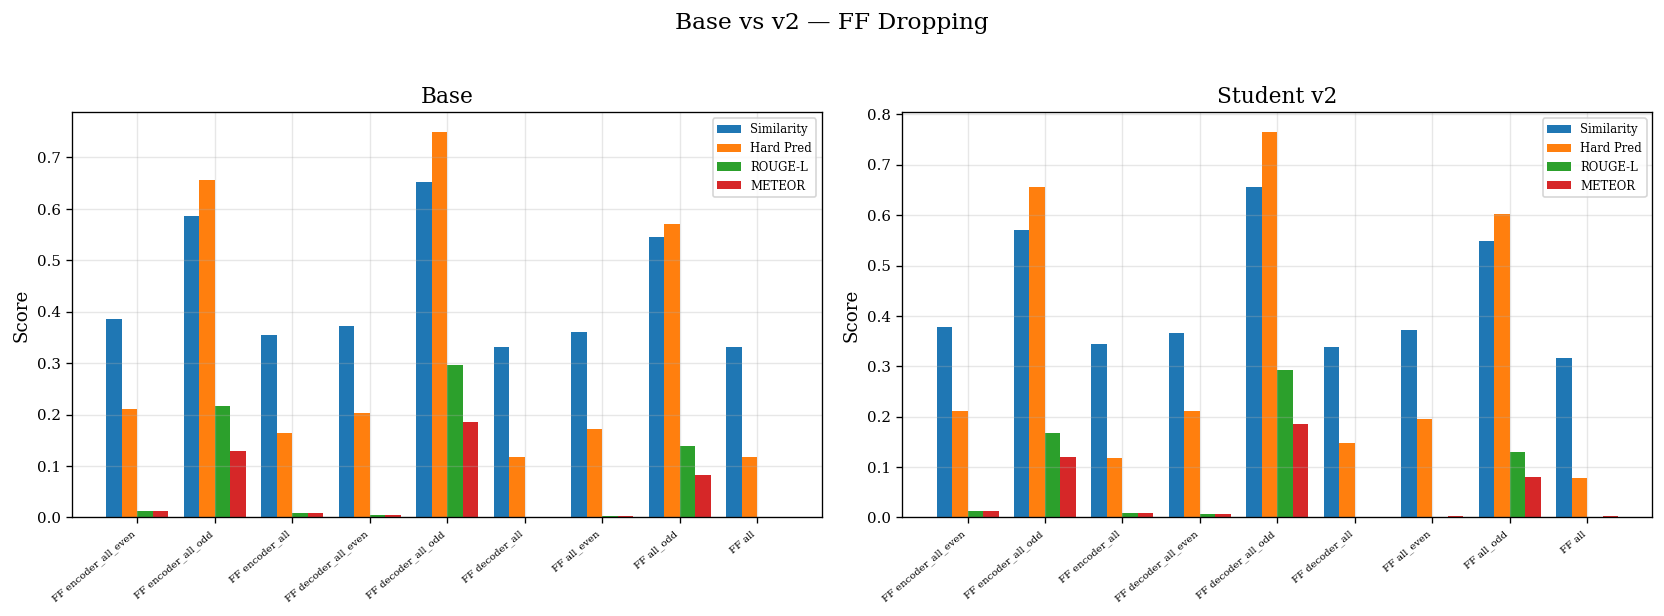

In [13]:
ff_keys = [
    'drop_feed_forward_encoder_all_even', 'drop_feed_forward_encoder_all_odd', 'drop_feed_forward_encoder_all',
    'drop_feed_forward_decoder_all_even', 'drop_feed_forward_decoder_all_odd', 'drop_feed_forward_decoder_all',
    'drop_feed_forward_all_even', 'drop_feed_forward_all_odd', 'drop_feed_forward_all',
]

def build_ff(results):
    rows = []
    for k in ff_keys:
        if k in results:
            v = results[k]
            rows.append({'exp': k.replace('drop_feed_forward_','FF '),
                         'Sim': v['similarity_mean'], 'Hard': v['similarity_hard_prediction_mean'],
                         'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title in [(axes[0], flan_base, 'Base'), (axes[1], flan_v2, 'Student v2')]:
    df = build_ff(results)
    x = np.arange(len(df)); w = 0.2
    ax.bar(x-1.5*w, df['Sim'], w, label='Similarity')
    ax.bar(x-0.5*w, df['Hard'], w, label='Hard Pred')
    ax.bar(x+0.5*w, df['ROUGE-L'], w, label='ROUGE-L')
    ax.bar(x+1.5*w, df['METEOR'], w, label='METEOR')
    ax.set_xticks(x); ax.set_xticklabels(df['exp'], rotation=40, ha='right', fontsize=6)
    ax.set_ylabel('Score'); ax.set_title(title); ax.legend(fontsize=7)
fig.suptitle('Base vs v2 — FF Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.6 Attention Masking

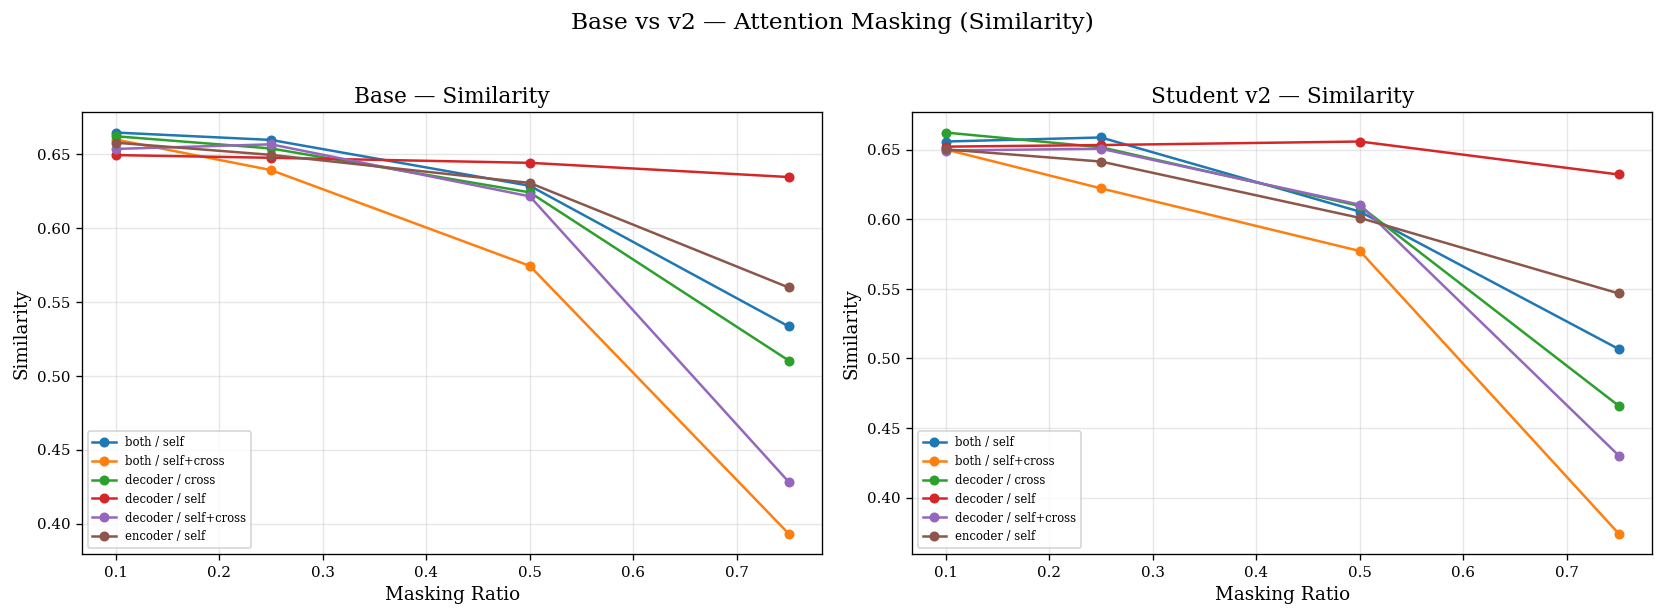

In [14]:
df_attn_v2 = parse_attention_masking(flan_v2, bl_v2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_attn_masking(df_attn_base, 'Base — Similarity', axes[0])
plot_attn_masking(df_attn_v2, 'Student v2 — Similarity', axes[1])
fig.suptitle('Base vs v2 — Attention Masking (Similarity)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

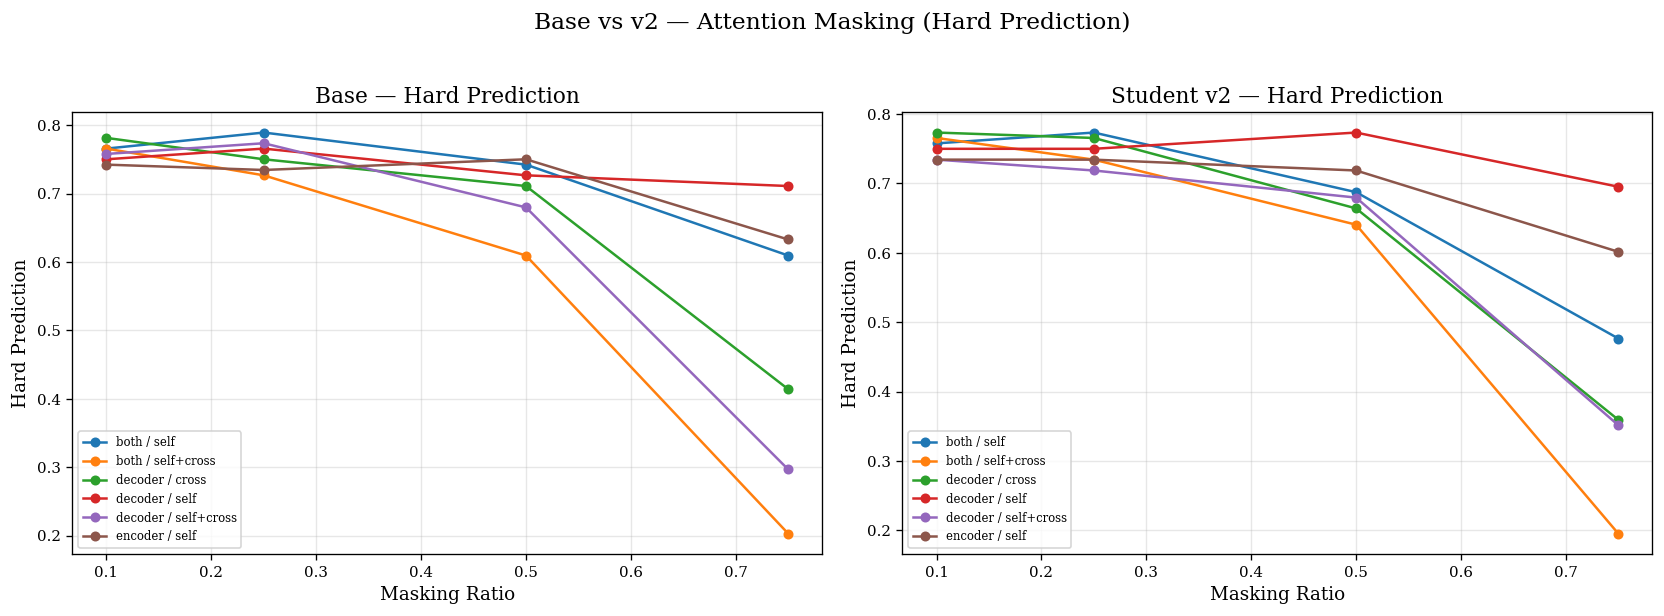

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], df_attn_base, 'Base'), (axes[1], df_attn_v2, 'Student v2')]:
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['Hard Pred'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('Hard Prediction')
    ax.set_title(f'{title} — Hard Prediction'); ax.legend(fontsize=7, loc='lower left')
fig.suptitle('Base vs v2 — Attention Masking (Hard Prediction)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.7 FF Masking

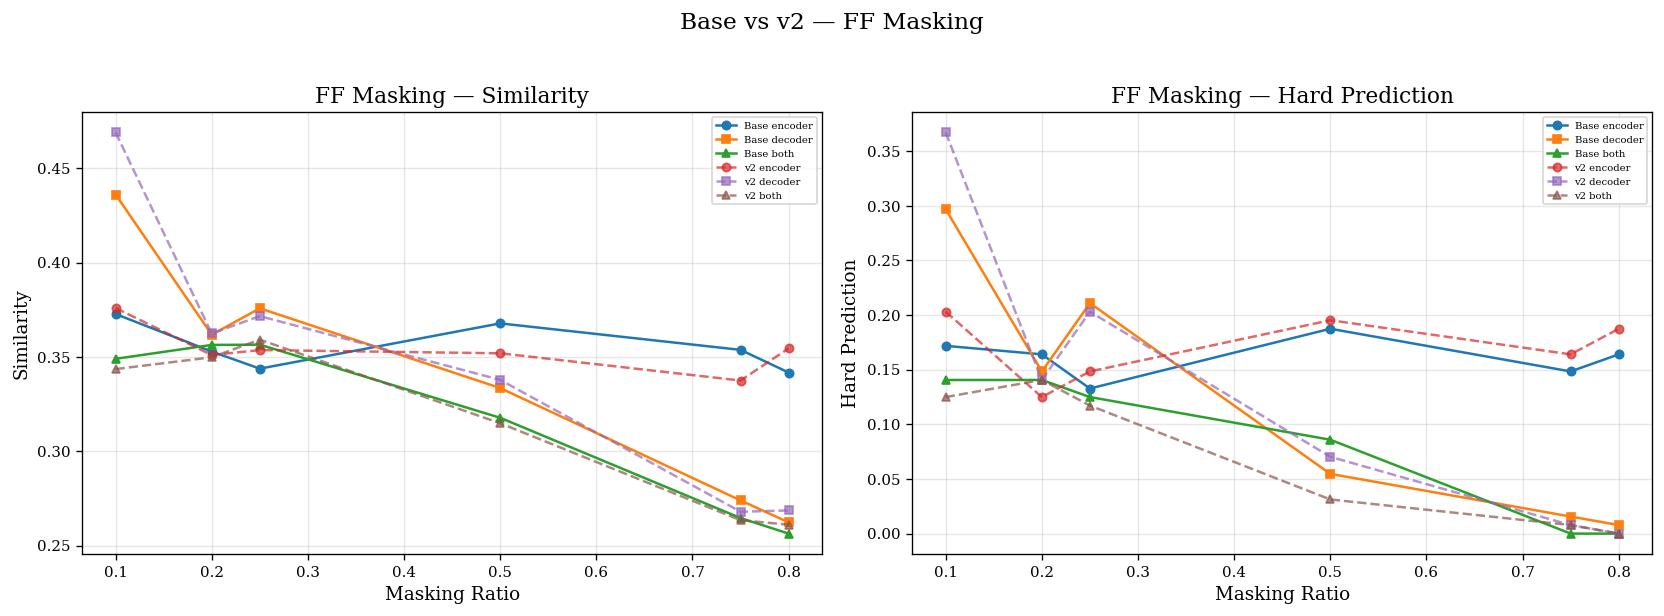

In [16]:
def parse_ff_masking(results):
    rows = []
    for k, v in results.items():
        if not k.startswith('mask_') or 'feed_forward' not in k:
            continue
        ratio = float(k.split('_')[-1])
        scope = 'encoder' if 'encoder_feed_forward' in k or k.startswith('mask_encoder_') else (
                'decoder' if 'decoder_feed_forward' in k or k.startswith('mask_decoder_') else 'both')
        rows.append({'scope': scope, 'ratio': ratio, 'Sim': v['similarity_mean'],
                     'Hard': v['similarity_hard_prediction_mean'],
                     'ROUGE-L': v['rouge']['rougeL'], 'METEOR': v['meteor_mean']})
    return pd.DataFrame(rows)

df_ffm_base = parse_ff_masking(flan_base)
df_ffm_v2 = parse_ff_masking(flan_v2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, ylabel) in zip(axes, [('Sim', 'Similarity'), ('Hard', 'Hard Prediction')]):
    for scope, mk in [('encoder','o'), ('decoder','s'), ('both','^')]:
        sub = df_ffm_base[df_ffm_base['scope']==scope].sort_values('ratio')
        if len(sub)>0: ax.plot(sub['ratio'], sub[col], f'{mk}-', label=f'Base {scope}', markersize=5)
    for scope, mk in [('encoder','o'), ('decoder','s'), ('both','^')]:
        sub = df_ffm_v2[df_ffm_v2['scope']==scope].sort_values('ratio')
        if len(sub)>0: ax.plot(sub['ratio'], sub[col], f'{mk}--', label=f'v2 {scope}', markersize=5, alpha=0.7)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel(ylabel)
    ax.set_title(f'FF Masking — {ylabel}'); ax.legend(fontsize=6)
fig.suptitle('Base vs v2 — FF Masking', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 2.8 Gaussian Noise

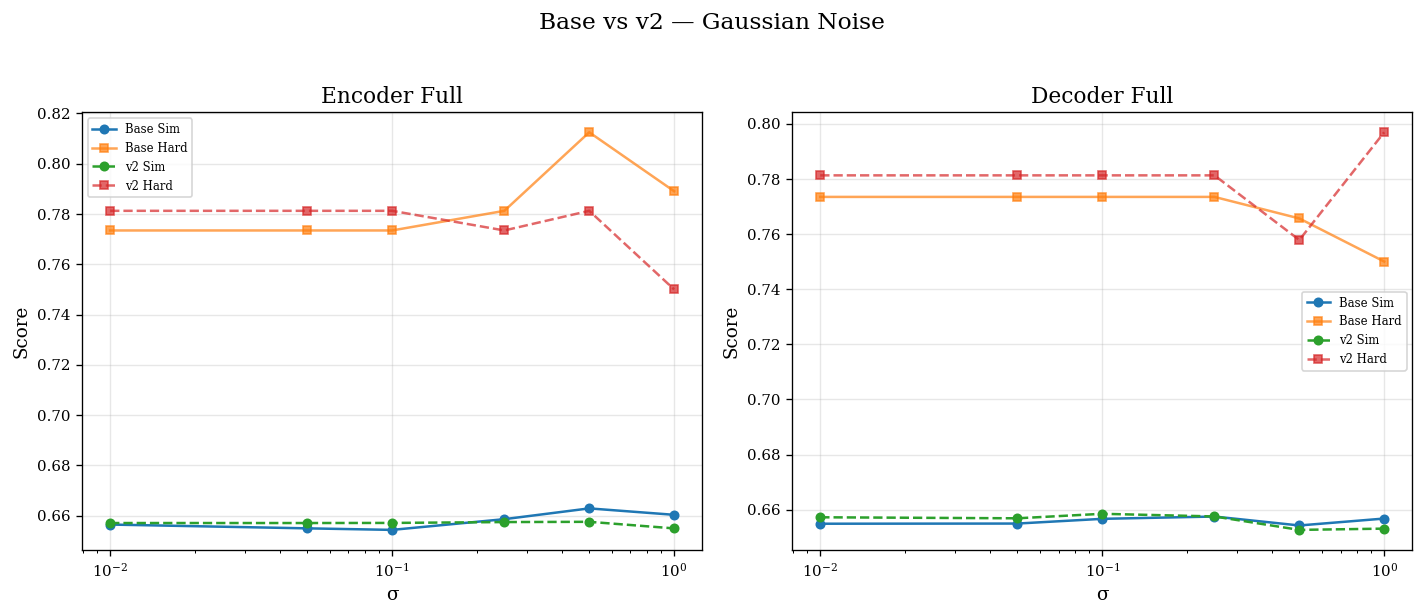

In [17]:
df_g_v2 = parse_gaussian(flan_v2, bl_v2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scope_key, title in [(axes[0], 'encoder full', 'Encoder Full'), (axes[1], 'decoder full', 'Decoder Full')]:
    for df, lbl, ls in [(df_g_base, 'Base', '-'), (df_g_v2, 'v2', '--')]:
        sub = df[df['scope'] == scope_key].sort_values('sigma')
        ax.plot(sub['sigma'], sub['Similarity'], f'o{ls}', label=f'{lbl} Sim', markersize=5)
        ax.plot(sub['sigma'], sub['Hard Pred'], f's{ls}', label=f'{lbl} Hard', markersize=5, alpha=0.7)
    ax.set_xlabel('σ'); ax.set_ylabel('Score'); ax.set_title(title)
    ax.legend(fontsize=7); ax.set_xscale('log')
fig.suptitle('Base vs v2 — Gaussian Noise', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 3. Student v1 vs Student v2

### 3.1 Single Layer Dropping

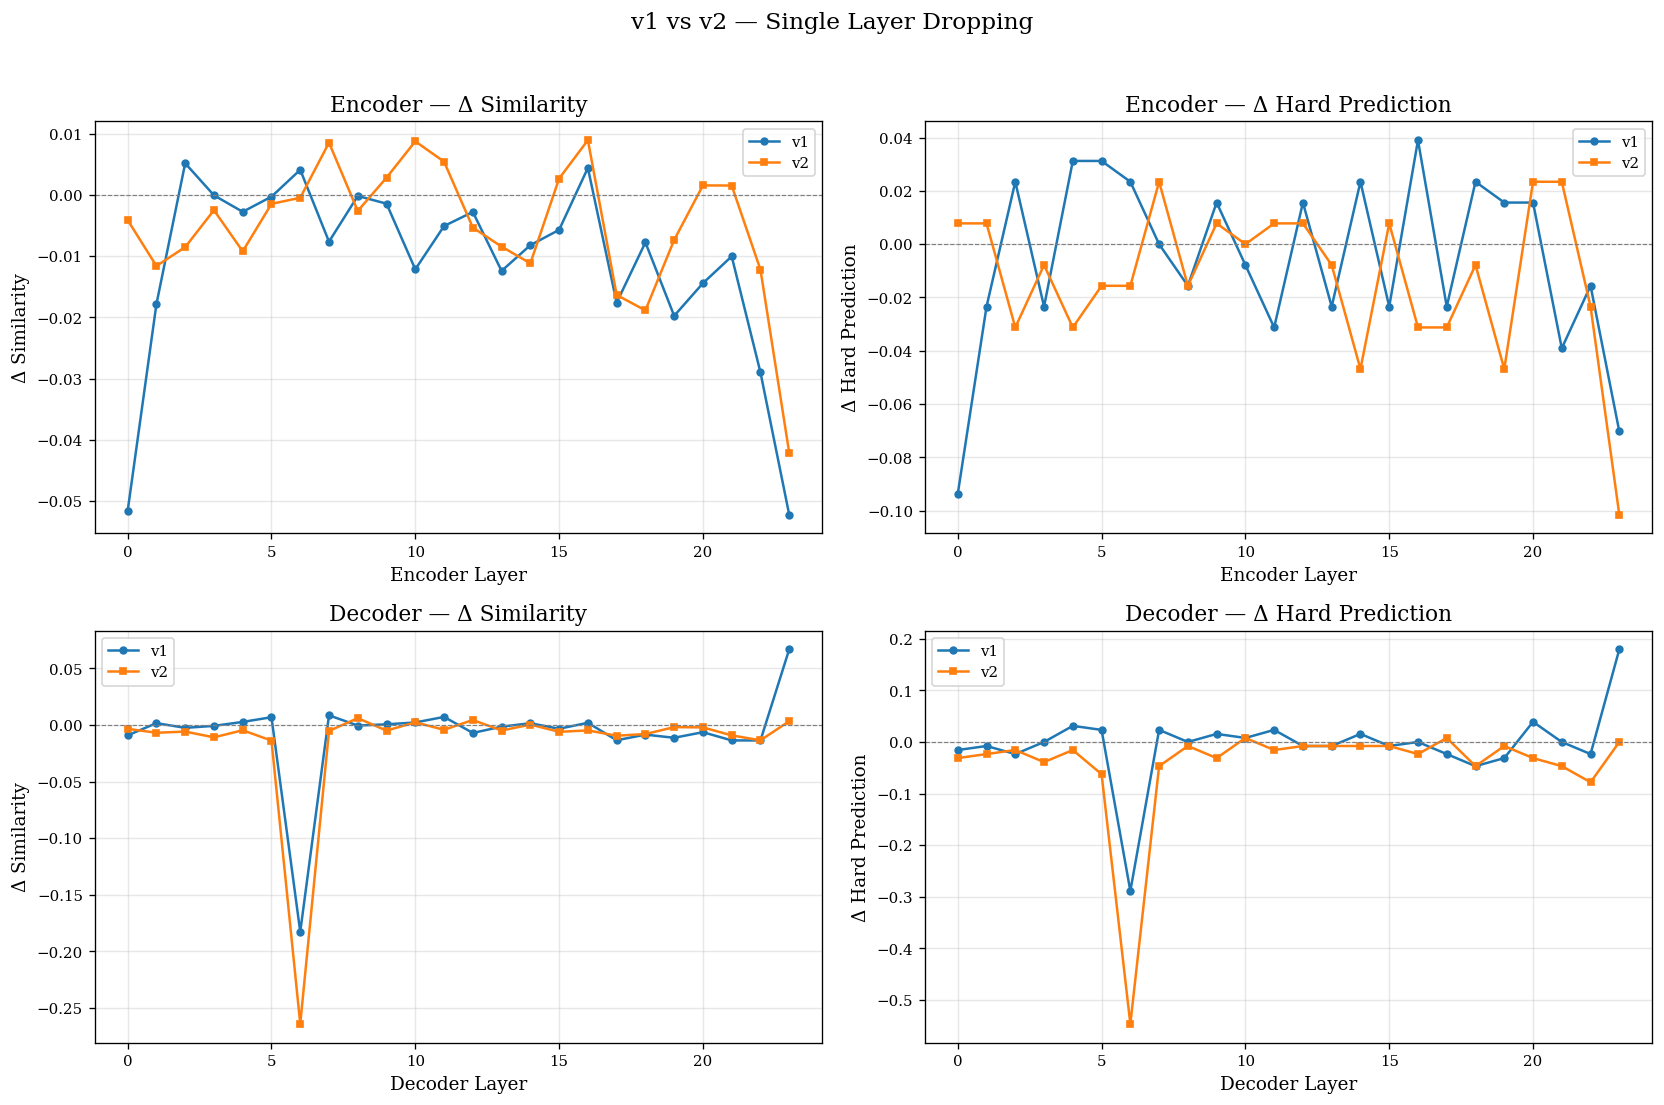

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, comp in enumerate(['encoder', 'decoder']):
    df_1 = get_layer_deltas(flan_v1, bl_v1, comp)
    df_2 = get_layer_deltas(flan_v2, bl_v2, comp)
    for col, (metric, label) in enumerate([('delta_sim', 'Δ Similarity'), ('delta_hard', 'Δ Hard Prediction')]):
        ax = axes[row, col]
        ax.plot(df_1['layer'], df_1[metric], 'o-', label='v1', markersize=4)
        ax.plot(df_2['layer'], df_2[metric], 's-', label='v2', markersize=4)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
        ax.set_xlabel(f'{comp.title()} Layer'); ax.set_ylabel(label)
        ax.set_title(f'{comp.title()} — {label}'); ax.legend()
fig.suptitle('v1 vs v2 — Single Layer Dropping', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 3.2 Cumulative Dropping

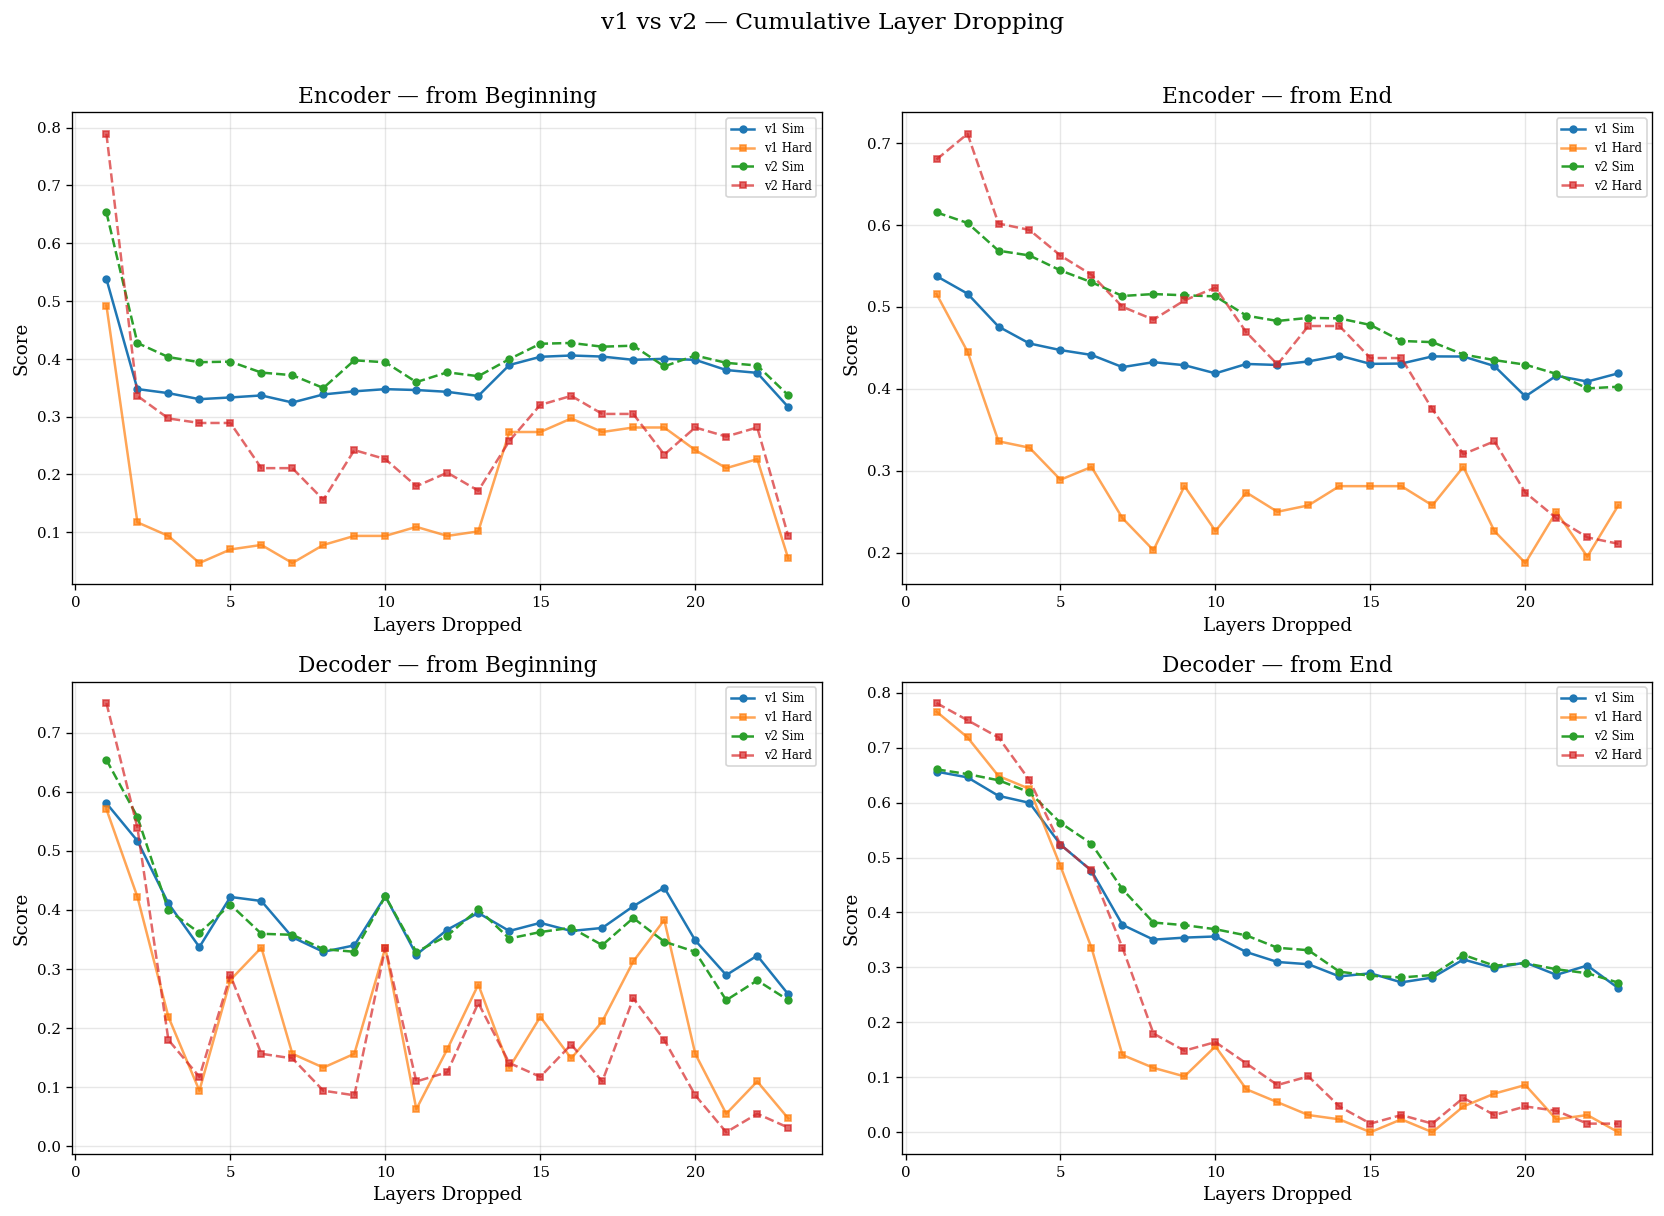

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, comp, direction, title in [
    (axes[0,0], 'encoder', 'beginning', 'Encoder — from Beginning'),
    (axes[0,1], 'encoder', 'end', 'Encoder — from End'),
    (axes[1,0], 'decoder', 'beginning', 'Decoder — from Beginning'),
    (axes[1,1], 'decoder', 'end', 'Decoder — from End'),
]:
    for results, lbl, ls in [(flan_v1, 'v1', '-'), (flan_v2, 'v2', '--')]:
        df = get_cumulative(results, comp, direction)
        if len(df) > 0:
            ax.plot(df['dropped'], df['sim'], f'o{ls}', label=f'{lbl} Sim', markersize=4)
            ax.plot(df['dropped'], df['hard'], f's{ls}', label=f'{lbl} Hard', markersize=4, alpha=0.7)
    ax.set_xlabel('Layers Dropped'); ax.set_ylabel('Score')
    ax.set_title(title); ax.legend(fontsize=7)
fig.suptitle('v1 vs v2 — Cumulative Layer Dropping', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### 3.3 Odd/Even + FF Dropping

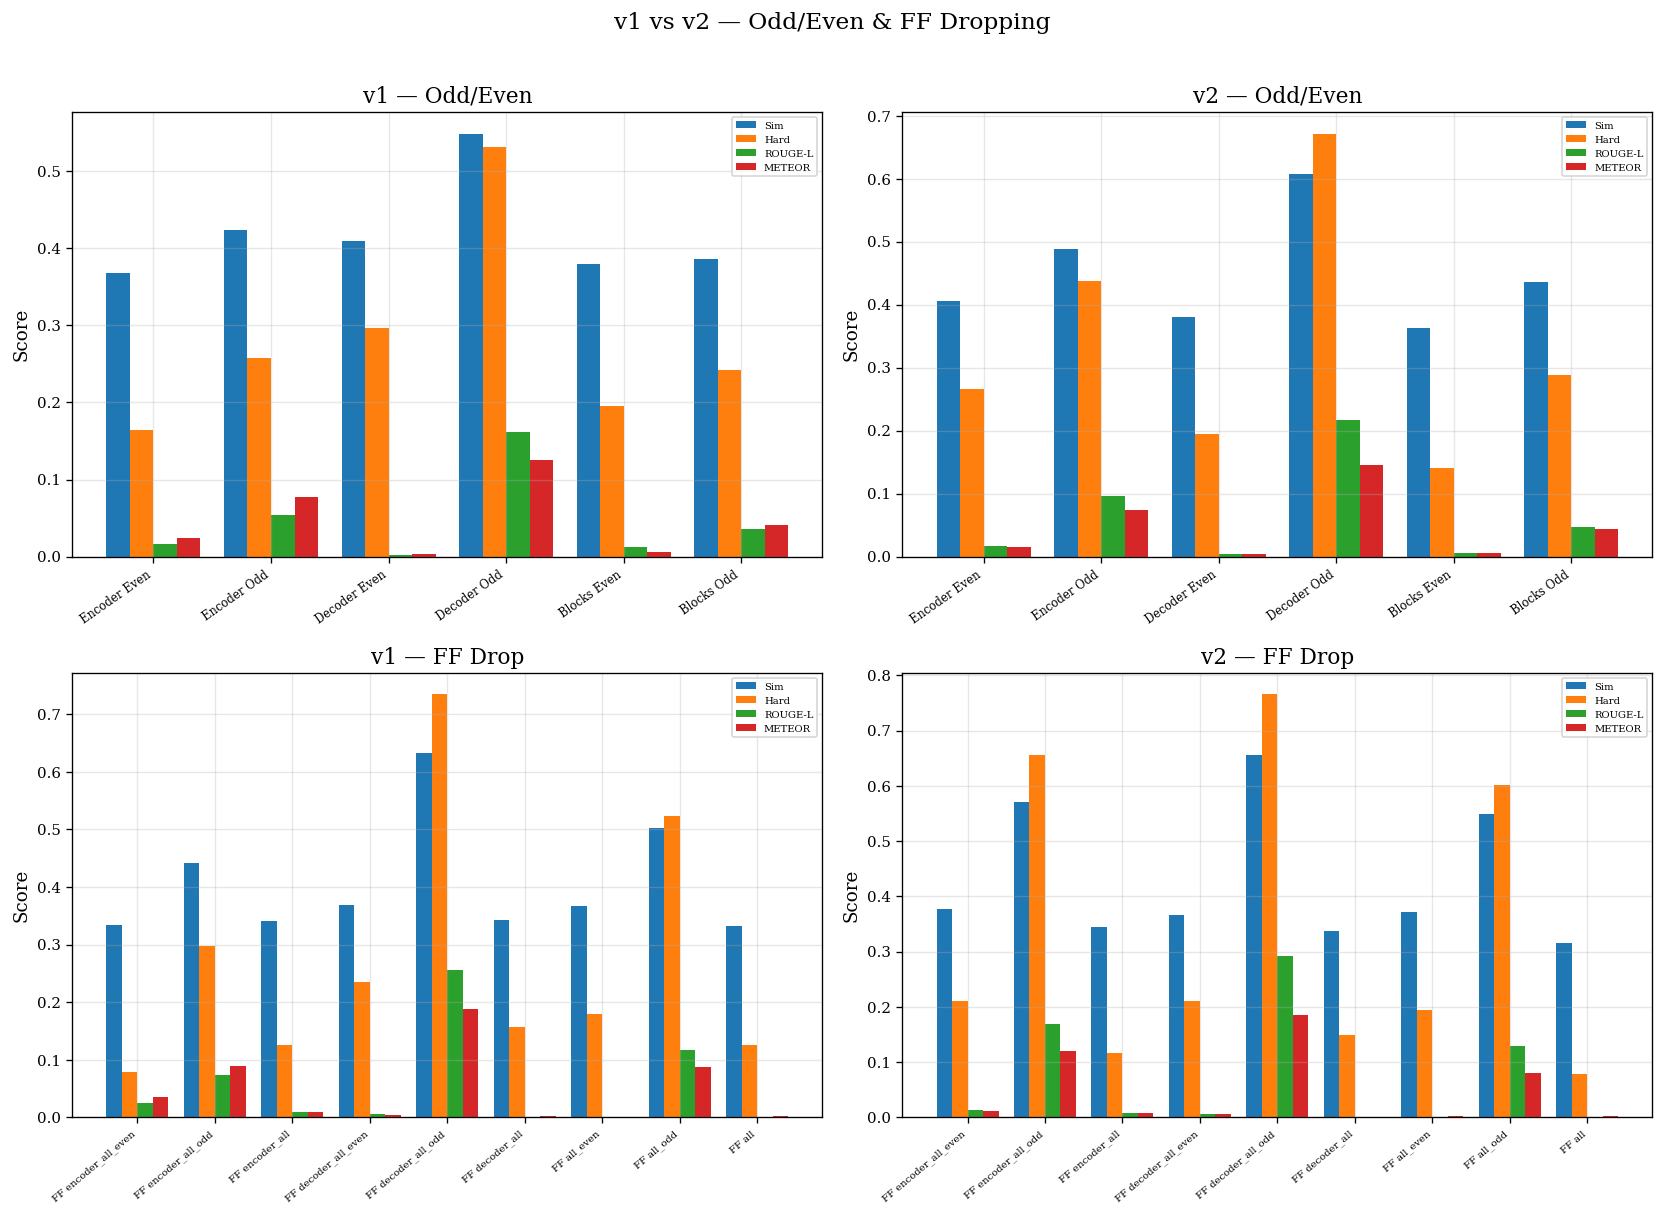

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Odd/Even
for ax, results, title in [(axes[0,0], flan_v1, 'v1 — Odd/Even'), (axes[0,1], flan_v2, 'v2 — Odd/Even')]:
    df = build_oe(results, None)
    x = np.arange(len(df)); w = 0.2
    ax.bar(x-1.5*w, df['Sim'], w, label='Sim')
    ax.bar(x-0.5*w, df['Hard'], w, label='Hard')
    ax.bar(x+0.5*w, df['ROUGE-L'], w, label='ROUGE-L')
    ax.bar(x+1.5*w, df['METEOR'], w, label='METEOR')
    ax.set_xticks(x); ax.set_xticklabels(df['exp'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('Score'); ax.set_title(title); ax.legend(fontsize=6)
# FF
for ax, results, title in [(axes[1,0], flan_v1, 'v1 — FF Drop'), (axes[1,1], flan_v2, 'v2 — FF Drop')]:
    df = build_ff(results)
    x = np.arange(len(df)); w = 0.2
    ax.bar(x-1.5*w, df['Sim'], w, label='Sim')
    ax.bar(x-0.5*w, df['Hard'], w, label='Hard')
    ax.bar(x+0.5*w, df['ROUGE-L'], w, label='ROUGE-L')
    ax.bar(x+1.5*w, df['METEOR'], w, label='METEOR')
    ax.set_xticks(x); ax.set_xticklabels(df['exp'], rotation=40, ha='right', fontsize=6)
    ax.set_ylabel('Score'); ax.set_title(title); ax.legend(fontsize=6)
fig.suptitle('v1 vs v2 — Odd/Even & FF Dropping', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### 3.4 Attention Masking

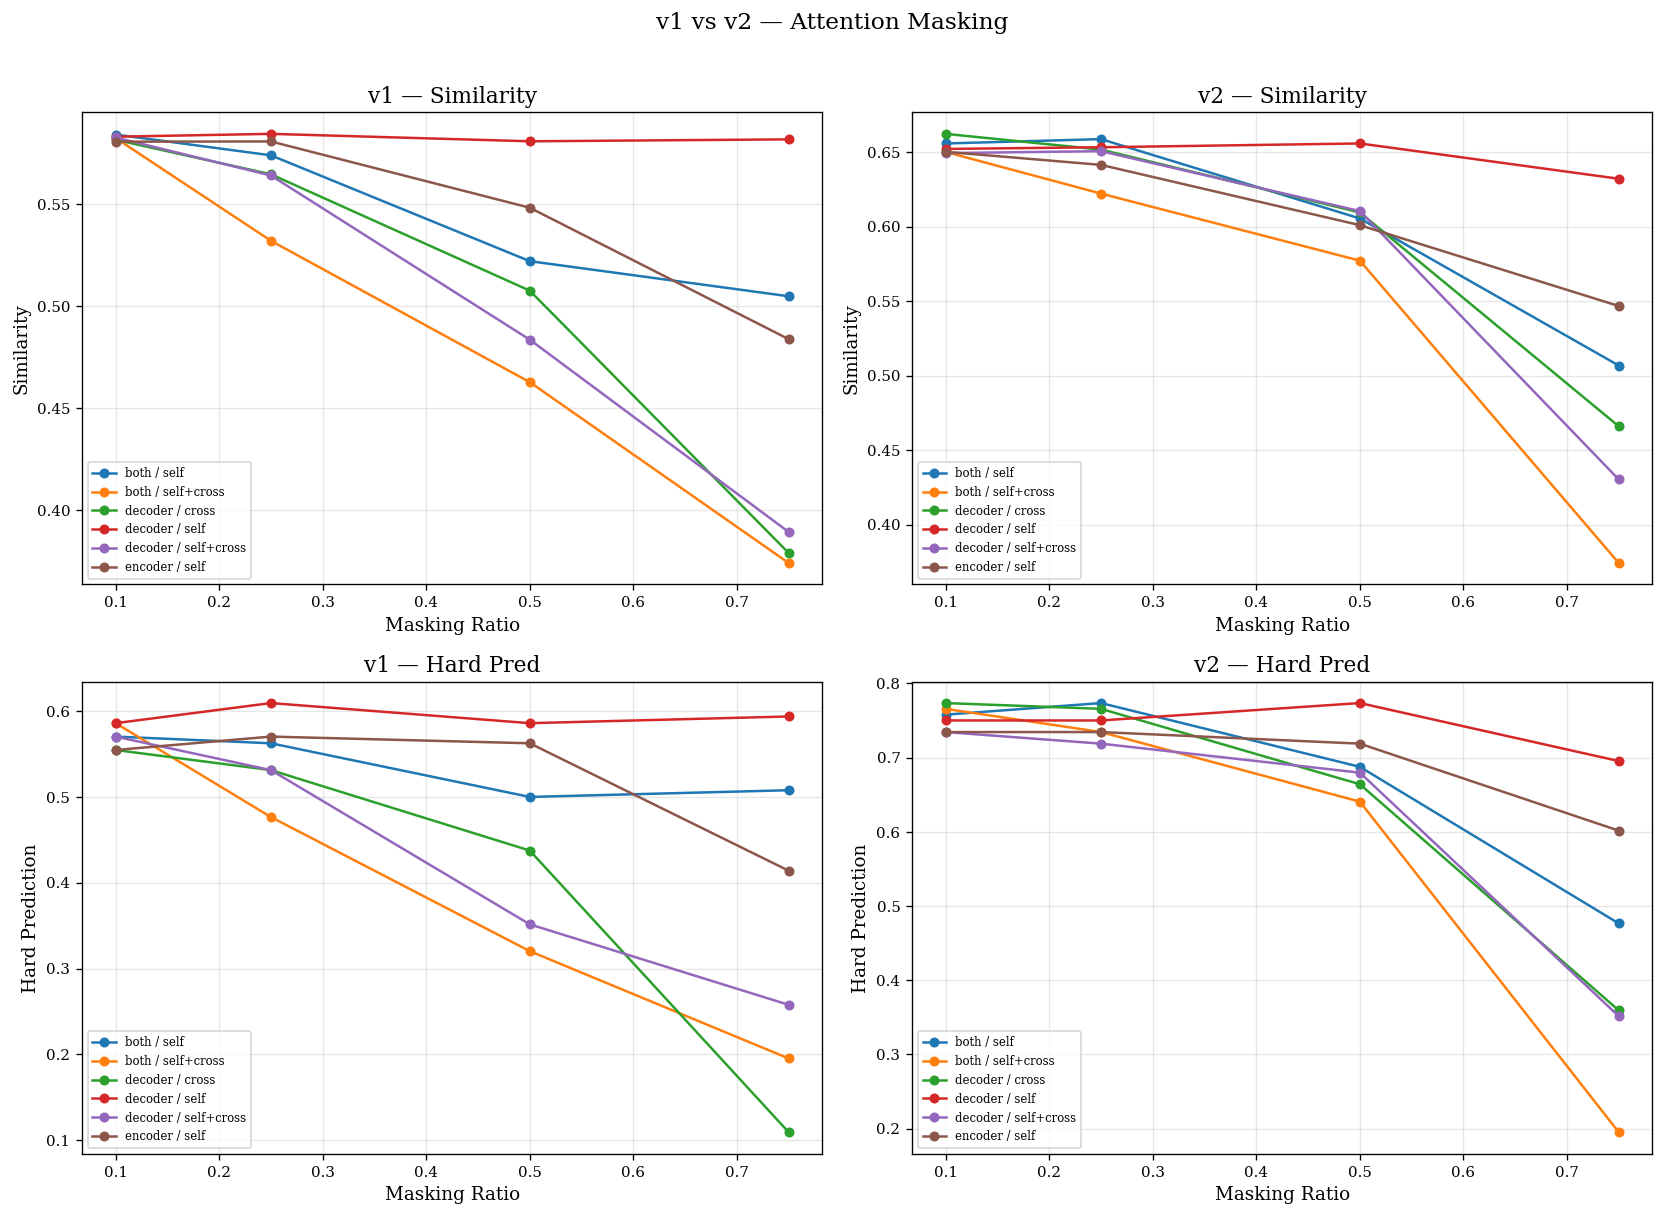

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_attn_masking(df_attn_v1, 'v1 — Similarity', axes[0,0])
plot_attn_masking(df_attn_v2, 'v2 — Similarity', axes[0,1])
# Hard prediction
for ax, df, title in [(axes[1,0], df_attn_v1, 'v1'), (axes[1,1], df_attn_v2, 'v2')]:
    for name, grp in df.groupby(['scope', 'attn_type']):
        g = grp.sort_values('ratio')
        ax.plot(g['ratio'], g['Hard Pred'], 'o-', label=f'{name[0]} / {name[1]}', markersize=5)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel('Hard Prediction')
    ax.set_title(f'{title} — Hard Pred'); ax.legend(fontsize=7, loc='lower left')
fig.suptitle('v1 vs v2 — Attention Masking', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### 3.5 FF Masking

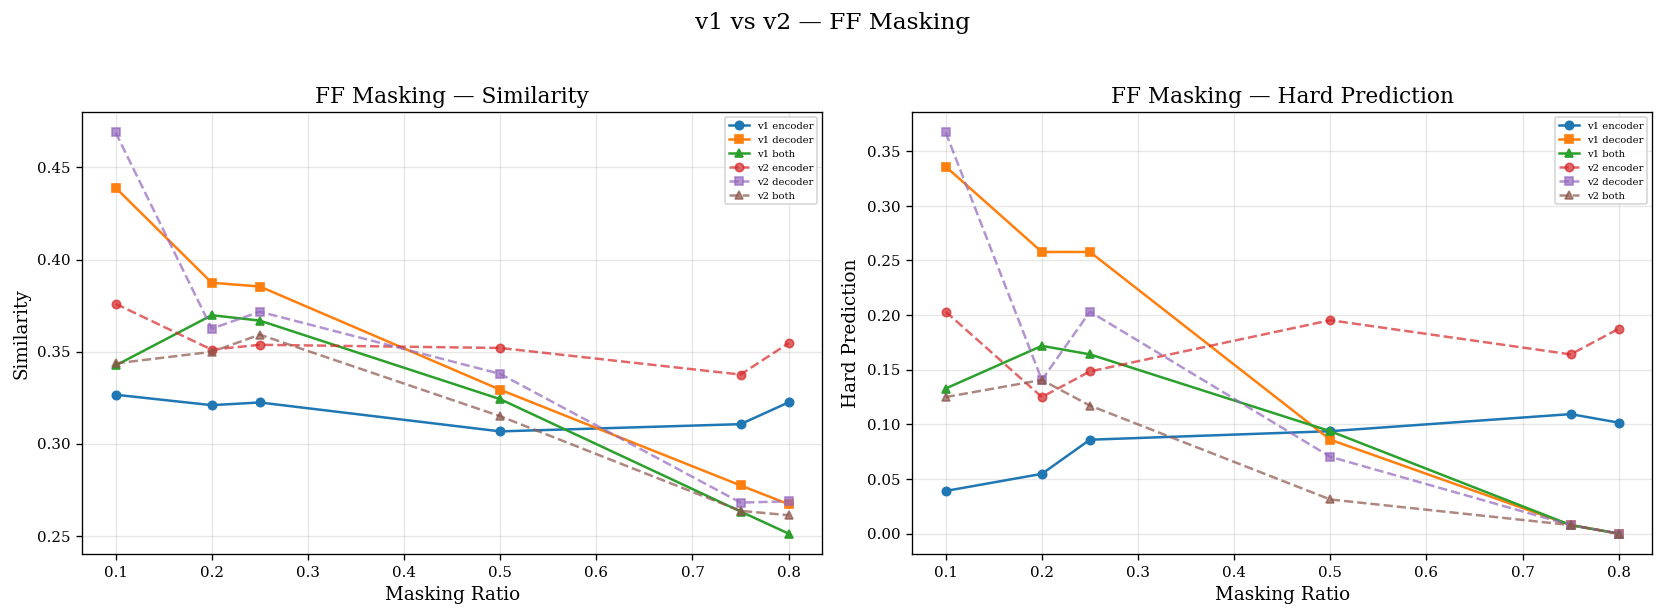

In [22]:
df_ffm_v1 = parse_ff_masking(flan_v1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, ylabel) in zip(axes, [('Sim', 'Similarity'), ('Hard', 'Hard Prediction')]):
    for scope, mk in [('encoder','o'), ('decoder','s'), ('both','^')]:
        sub = df_ffm_v1[df_ffm_v1['scope']==scope].sort_values('ratio')
        if len(sub)>0: ax.plot(sub['ratio'], sub[col], f'{mk}-', label=f'v1 {scope}', markersize=5)
    for scope, mk in [('encoder','o'), ('decoder','s'), ('both','^')]:
        sub = df_ffm_v2[df_ffm_v2['scope']==scope].sort_values('ratio')
        if len(sub)>0: ax.plot(sub['ratio'], sub[col], f'{mk}--', label=f'v2 {scope}', markersize=5, alpha=0.7)
    ax.set_xlabel('Masking Ratio'); ax.set_ylabel(ylabel)
    ax.set_title(f'FF Masking — {ylabel}'); ax.legend(fontsize=6)
fig.suptitle('v1 vs v2 — FF Masking', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 3.6 Gaussian Noise

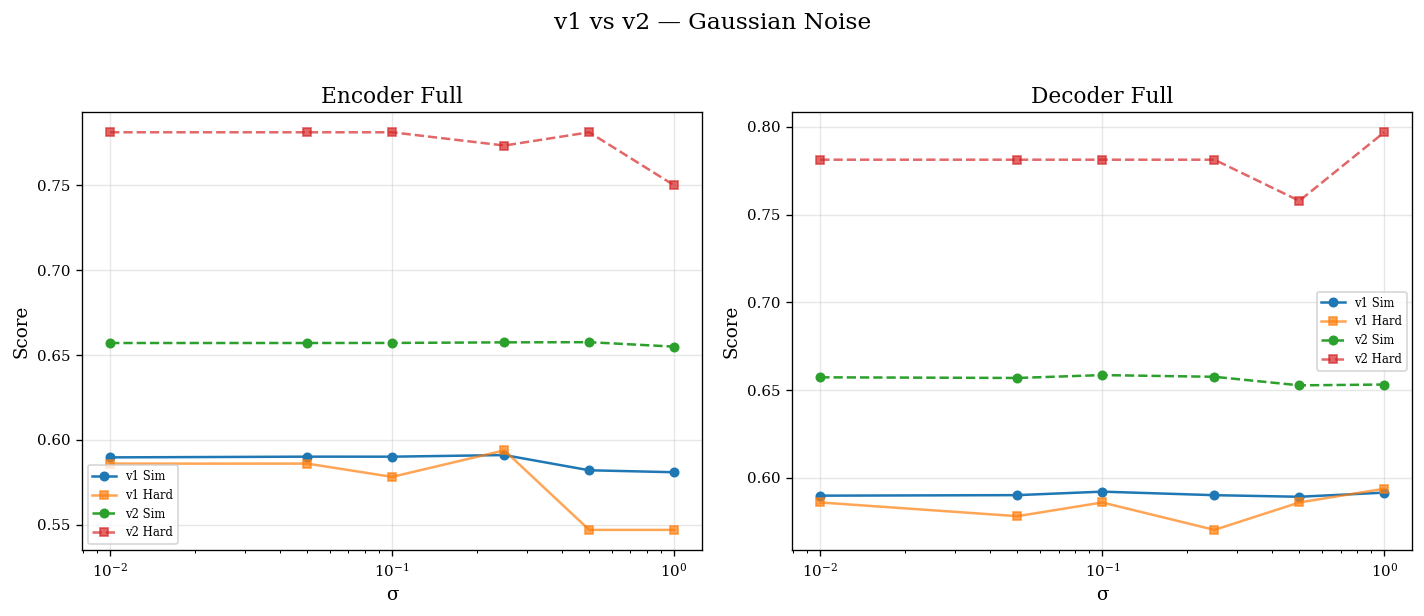

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scope_key, title in [(axes[0], 'encoder full', 'Encoder Full'), (axes[1], 'decoder full', 'Decoder Full')]:
    for df, lbl, ls in [(df_g_v1, 'v1', '-'), (df_g_v2, 'v2', '--')]:
        sub = df[df['scope'] == scope_key].sort_values('sigma')
        ax.plot(sub['sigma'], sub['Similarity'], f'o{ls}', label=f'{lbl} Sim', markersize=5)
        ax.plot(sub['sigma'], sub['Hard Pred'], f's{ls}', label=f'{lbl} Hard', markersize=5, alpha=0.7)
    ax.set_xlabel('σ'); ax.set_ylabel('Score'); ax.set_title(title)
    ax.legend(fontsize=7); ax.set_xscale('log')
fig.suptitle('v1 vs v2 — Gaussian Noise', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## Summary Heatmap

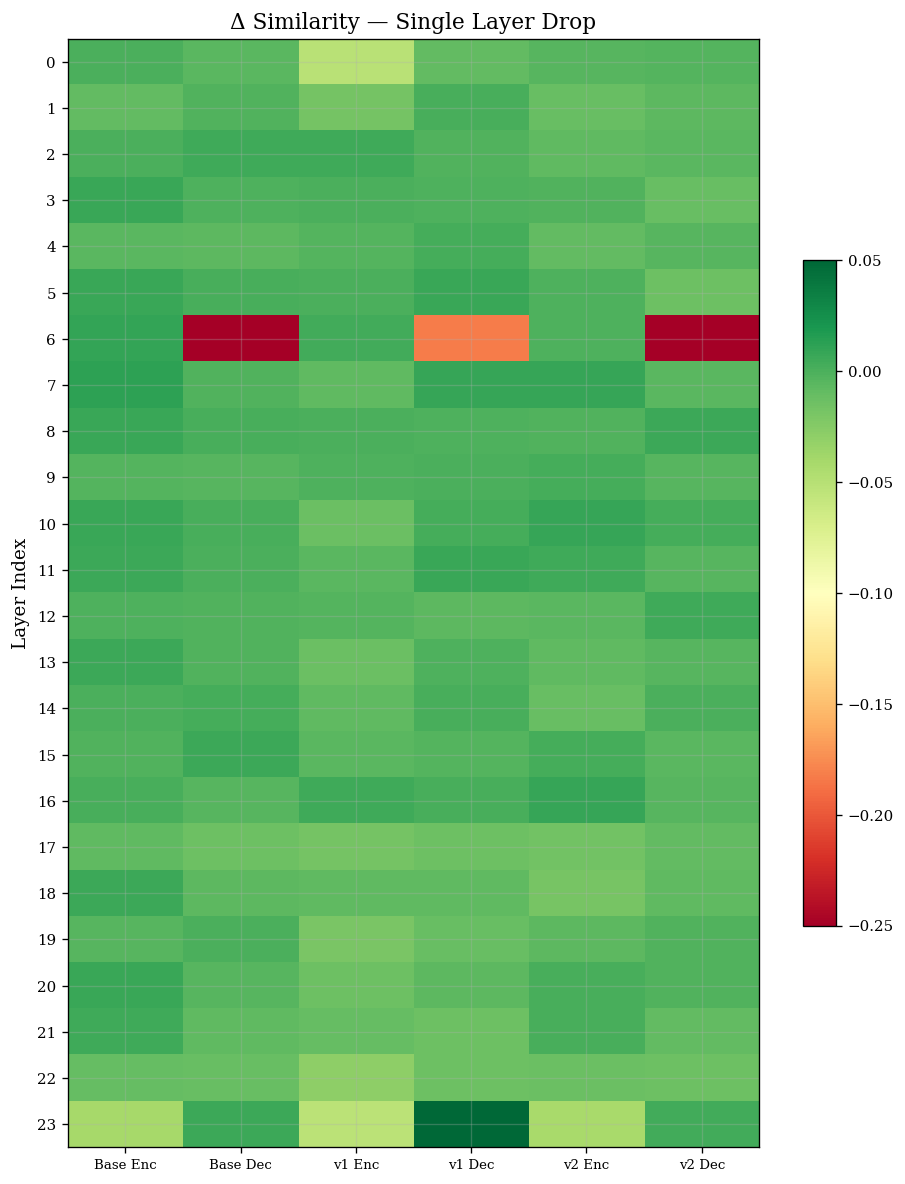

In [24]:
n = 24
heat = np.full((n, 6), np.nan)
cols = ['Base Enc', 'Base Dec', 'v1 Enc', 'v1 Dec', 'v2 Enc', 'v2 Dec']
for i in range(n):
    for j, (res, bl, comp) in enumerate([
        (flan_base, bl_base, 'encoder'), (flan_base, bl_base, 'decoder'),
        (flan_v1, bl_v1, 'encoder'), (flan_v1, bl_v1, 'decoder'),
        (flan_v2, bl_v2, 'encoder'), (flan_v2, bl_v2, 'decoder'),
    ]):
        k = f'drop_{comp}_block_{i}'
        if k in res:
            heat[i, j] = res[k]['similarity_mean'] - bl['similarity_mean']

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heat, cmap='RdYlGn', aspect='auto', vmin=-0.25, vmax=0.05)
ax.set_xticks(range(6)); ax.set_xticklabels(cols, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(range(n))
ax.set_ylabel('Layer Index'); ax.set_title('Δ Similarity — Single Layer Drop')
plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout(); plt.show()